In [1]:
import os
os.chdir('..')
print("current working directory:", os.getcwd())

current working directory: e:\Portfolio Project\GREEN HARVEST SEEDS INDIA PVT. LTD\Project


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/raw/india_agriculture_seed_sales_data.csv')


In [4]:
## Null Check
print("Nulls:", df.isnull().sum().sum())

Nulls: 0


In [6]:
## Unique values

print("Regions:", df['Region'].unique())           # 5 regions
print("States:", df['State'].nunique())             # 18 states
print("Vegetables:", df['Vegetable_Type'].unique()) # 20 crops
print("Year Range:", df['Year'].min(), '–', df['Year'].max())

Regions: <StringArray>
['Central', 'East', 'North', 'South', 'West']
Length: 5, dtype: str
States: 18
Vegetables: <StringArray>
['Bitter Gourd', 'Bottle Gourd',      'Brinjal',      'Cabbage',
       'Carrot',  'Cauliflower',        'Chili',    'Coriander',
     'Cucumber',    'Fenugreek',       'Garlic',   'Green Peas',
         'Okra',        'Onion',       'Potato',      'Pumpkin',
       'Radish',  'Ridge Gourd',      'Spinach',       'Tomato']
Length: 20, dtype: str
Year Range: 2021 – 2025


 Revenue Trend by Year

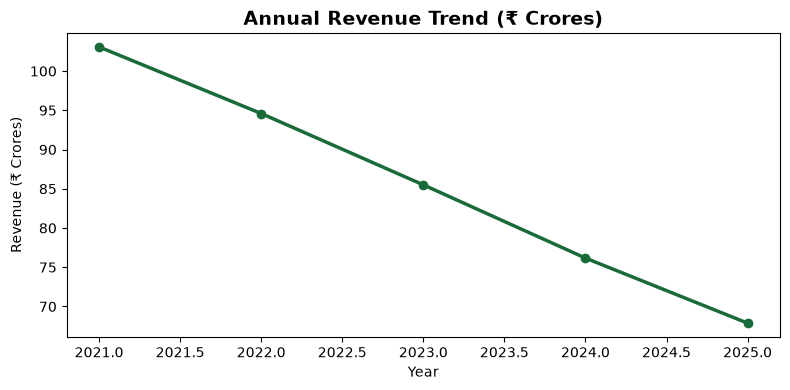

In [10]:
rev_year = df.groupby('Year')['Total_Revenue'].sum() / 1e7  # in Crores
plt.figure(figsize=(8,4))
plt.plot(rev_year.index, rev_year.values, marker='o', color='#1a6b3a', linewidth=2.5)
plt.title('Annual Revenue Trend (₹ Crores)', fontsize=14, fontweight='bold')
plt.xlabel('Year'); plt.ylabel('Revenue (₹ Crores)')
plt.tight_layout(); plt.savefig('outputs/revenue_trend.png', dpi=150)


Profit Margin by Region

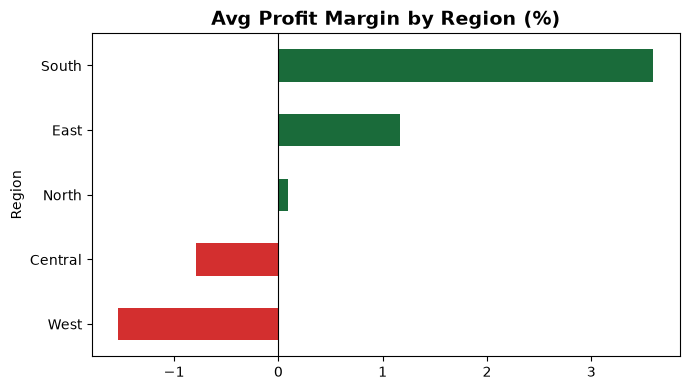

In [11]:
region_profit = df.groupby('Region')['Profit_Margin_%'].mean().sort_values()
plt.figure(figsize=(7,4))
colors = ['#d32f2f' if v < 0 else '#1a6b3a' for v in region_profit.values]
region_profit.plot(kind='barh', color=colors)
plt.title('Avg Profit Margin by Region (%)', fontsize=14, fontweight='bold')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout(); plt.savefig('outputs/region_profit.png', dpi=150)

Profit by Vegetable Type 

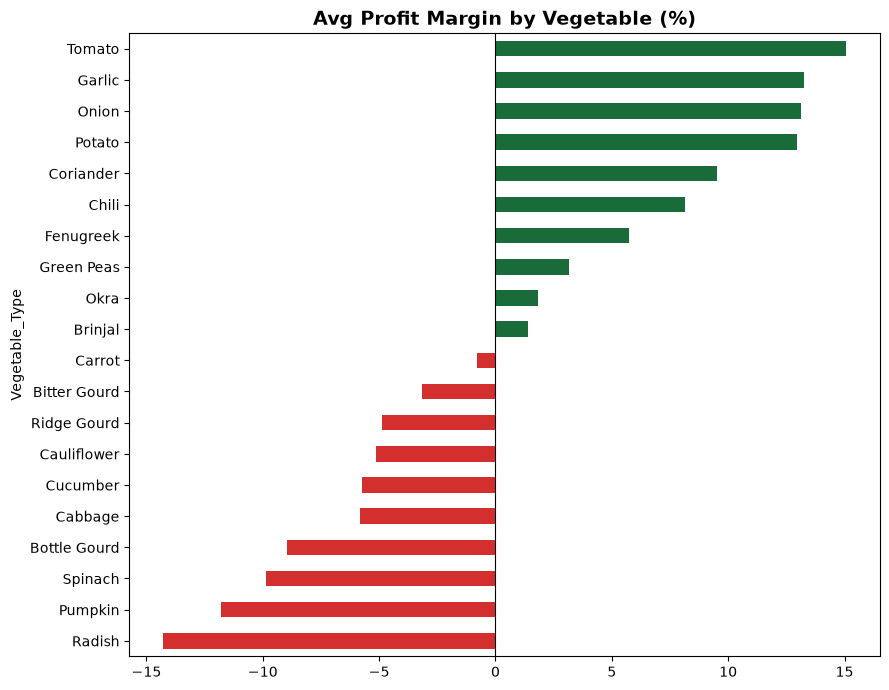

In [12]:
veg_profit = df.groupby('Vegetable_Type')['Profit_Margin_%'].mean().sort_values()
colors = ['#d32f2f' if v < 0 else '#1a6b3a' for v in veg_profit.values]
plt.figure(figsize=(9,7))
veg_profit.plot(kind='barh', color=colors)
plt.title('Avg Profit Margin by Vegetable (%)', fontsize=14, fontweight='bold')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout(); plt.savefig('outputs/vegetable_profit.png', dpi=150)

Correlation Heatmap

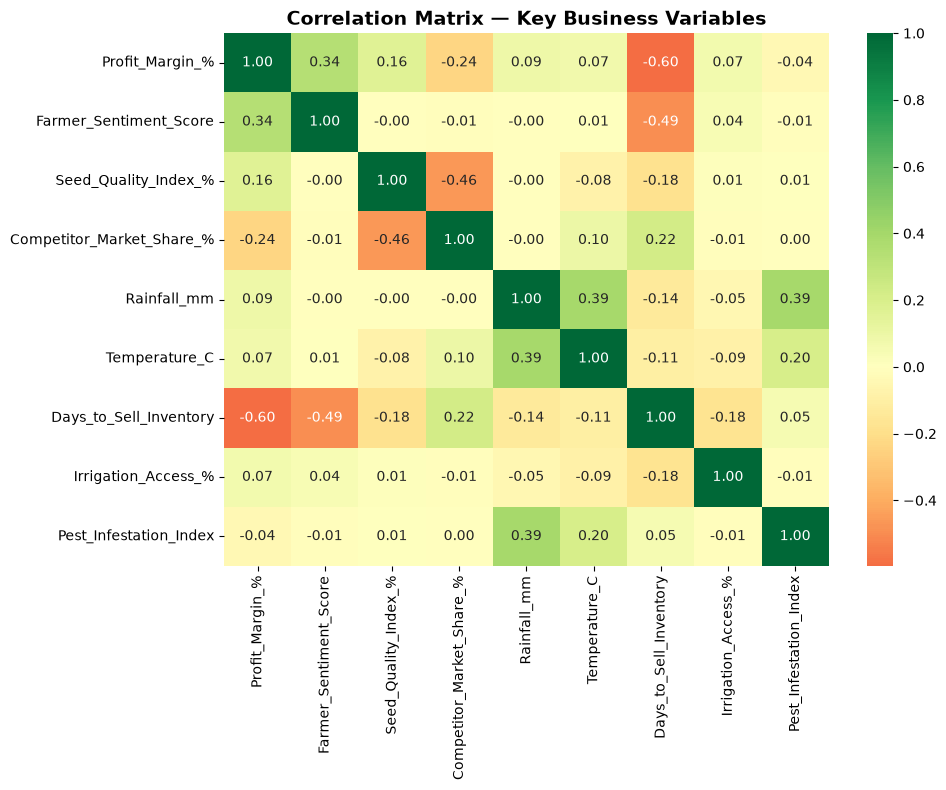

In [13]:
numeric_cols = ['Profit_Margin_%','Farmer_Sentiment_Score','Seed_Quality_Index_%',
                'Competitor_Market_Share_%','Rainfall_mm','Temperature_C',
                'Days_to_Sell_Inventory','Irrigation_Access_%','Pest_Infestation_Index']
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Correlation Matrix — Key Business Variables', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('outputs/correlation_heatmap.png', dpi=150)